## 📊 Part B: Practical

### Import Libraries

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import norm


### 📊Load Excel File

In [14]:
df = pd.read_excel('household_dataset_500_records.xlsx')
df.head()

,Household_ID,Age_of_Household_Head,Household_Income,Education_Level,Family_Size,Owns_House,Urban_Rural
0,HH0001,65,21012,Primary,3,Yes,Rural
1,HH0002,68,80741,Graduate,2,Yes,Urban
2,HH0003,30,41559,Secondary,6,Yes,Urban
3,HH0004,66,72493,Graduate,3,Yes,Urban
4,HH0005,25,55463,Graduate,7,Yes,Urban


## 🔹 3. Types of Data
### ✅ Question : Identify which columns are Categorical and which are Numerical.


In [15]:
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("numerical :- ", numerical_cols)
print("categorical :- ", categorical_cols)


numerical :-  ['Age_of_Household_Head', 'Household_Income', 'Family_Size']
categorical :-  ['Household_ID', 'Education_Level', 'Owns_House', 'Urban_Rural']


## 📈 4. Central Tendency
### ✅ Question 1 : Calculate the Mean, Median, and Mode of :- 💰 Household Income , Age 👨‍👩‍👧


In [8]:
income_mean = df['Household_Income'].mean()
income_median = df['Household_Income'].median()
income_mode = df['Household_Income'].mode()[0] 

age_mean = df['Age_of_Household_Head'].mean()
age_median = df['Age_of_Household_Head'].median()
age_mode = df['Age_of_Household_Head'].mode()[0]

print("--- Household Income Statistics ---")
print(f"Mean:   {income_mean:.2f}")
print(f"Median: {income_median:.2f}")
print(f"Mode:   {income_mode}")

print("\n--- Age Statistics ---")
print(f"Mean:   {age_mean:.2f}")
print(f"Median: {age_median:.2f}")
print(f"Mode:   {age_mode}")


--- Household Income Statistics ---
Mean:   57582.06
Median: 48138.50
Mode:   47847

--- Age Statistics ---
Mean:   50.12
Median: 50.00
Mode:   25


### 💡Insight :-
#### Mean income is higher than median income. Mean > Median ⇒ Positively Skewed Distribution

### ✅ Question 2 : Interpret the central tendency and comment on the income distribution.

### Ans:-
#####   [1] Household Income: The typical income is ₹48,138 (Median) [1]. A few high earners pull the mathematical average up to ₹57,582 (Mean), indicating a right-skewed distribution [1] .
#####  [2] Age: The sample centers perfectly at 50 years old (Mean/Median). However, 25 is the most common specific age (Mode), showing a major group of young household heads.


#### income data shows a classic Right-Skewed (Positively Skewed) Distribution.

Skewness Score: 0.91 (Positive score confirms Right-Skew)


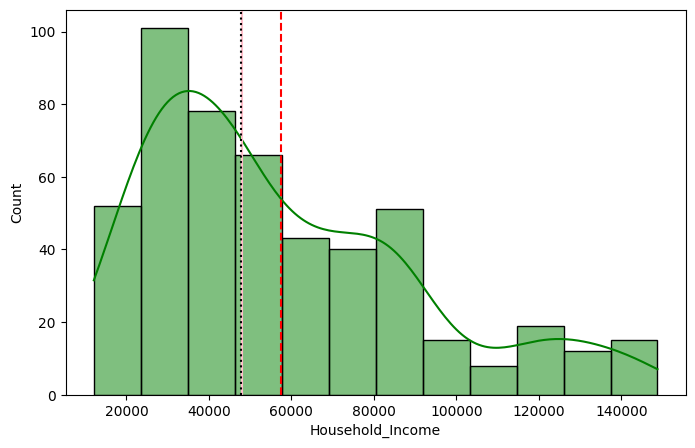

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

skewness = df['Household_Income'].skew()
print(f"Skewness Score: {skewness:.2f} (Positive score confirms Right-Skew)")

plt.figure(figsize=(8, 5))
sns.histplot(df['Household_Income'], kde=True, color='green')

plt.axvline(df['Household_Income'].mean(), color='red', linestyle='--')
plt.axvline(df['Household_Income'].median(), color='pink', linestyle='-')
plt.axvline(df['Household_Income'].mode()[0], color='black', linestyle=':')

plt.show()


## 📊 5. Measures of Dispersion
### ✅ Question 1 : Calculate:Range,Variance,Standard_Deviation of Household Income 

In [9]:
income_range = df['Household_Income'].max() - df['Household_Income'].min()
income_variance = df['Household_Income'].var()
income_std_dev = df['Household_Income'].std()

print("--- Household Income Dispersion ---")
print(f"Range:              {income_range:.2f}")
print(f"Variance:           {income_variance:.2f}")
print(f"Standard Deviation: {income_std_dev:.2f}")


--- Household Income Dispersion ---
Range:              136673.00
Variance:           1087458274.19
Standard Deviation: 32976.63


### 💡Insight : 
#### The dataset has a very large income range.

### ✅ Question 2 : Find the IQR (Interquartile Range) and comment on income spread.

In [34]:
Q1 = df['Household_Income'].quantile(0.25)
Q3 = df['Household_Income'].quantile(0.75)

IQR = Q3 - Q1

print(f"Q1 (25th Percentile): {Q1:.2f}")
print(f"Q3 (75th Percentile): {Q3:.2f}")
print(f"IQR(Interquartile Range): {IQR:.2f}")


Q1 (25th Percentile): 31328.00
Q3 (75th Percentile): 78881.25
IQR(Interquartile Range): 47553.25


### 💡Insight : 
#### The middle 50% of households have income spread over a wide range.

## 📉 6. Distribution Analysis
### ✅ Question 1 : Plot a Histogram of Household Income

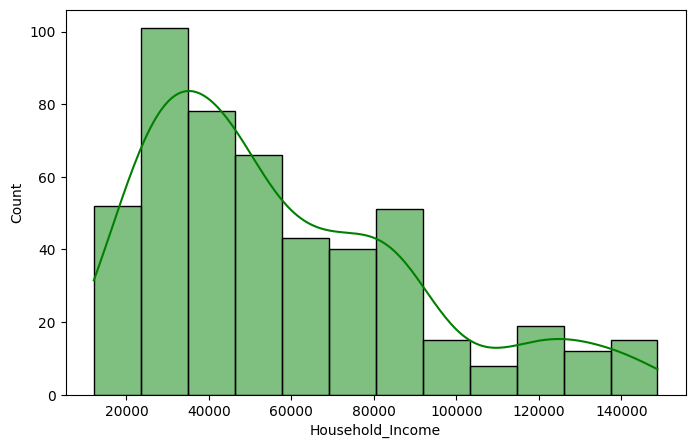

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(df['Household_Income'], kde=True, color='green', edgecolor='black')
plt.show()


### 📊 Histogram Insight :- 
#### Most household incomes are concentrated between ₹20,000 – ₹80,000.
##### 💰 Most households belong to the low-to-middle income group 
##### Right Tail Longer ⇒ Positive Skewness

### ✅ Question 2 : Fit a Gaussian Normal Distribution Curve 

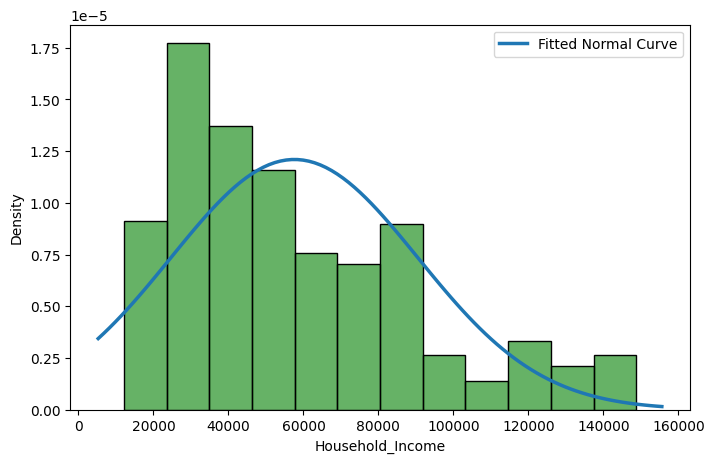

In [36]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Household_Income"],
    stat="density",
    color="Green",
    edgecolor="black",
    alpha=0.6,
)

mu = df["Household_Income"].mean()
sigma = df["Household_Income"].std()

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)

p = norm.pdf(x, mu, sigma)
plt.plot(x, p, linewidth=2.5, label="Fitted Normal Curve")

plt.legend()
plt.show()


### 📊 Insight :-
##### Right-Skewed Distribution: The data has a long right tail extending toward 160,000.
##### Concentrated Low Incomes: Most households earn between 20,000 and 50,000.

### ✅ Question 3 : Calculate: Skewness , Kurtosis , of the income data 📈

In [38]:
# Calculate Skewness and Kurtosis
income_skew = df['Household_Income'].skew()
income_kurt = df['Household_Income'].kurt()

print("--- Income Shape Statistics ---")
print(f"Skewness: {income_skew:.2f}")
print(f"Kurtosis: {income_kurt:.2f}")


--- Income Shape Statistics ---
Skewness: 0.91
Kurtosis: 0.11


### ✅ Skewness Insight :
##### Skewness=0.91 > 0   
##### Positive skewness confirms that the income distribution is right-skewed. High-income households pull the distribution toward the right.
### ✅ Kurtosis Insight : 
##### Kurtosis=0.11
##### Kurtosis is close to 0, meaning the distribution is close to normal in peak shape.

## 📦 7. Data Categorization
### ✅ Question : Use visualization techniques like : Boxplot 📦 , Histogram 📊 to compare household income across : Different education levels 🎓Urban vs Rural areas🌾

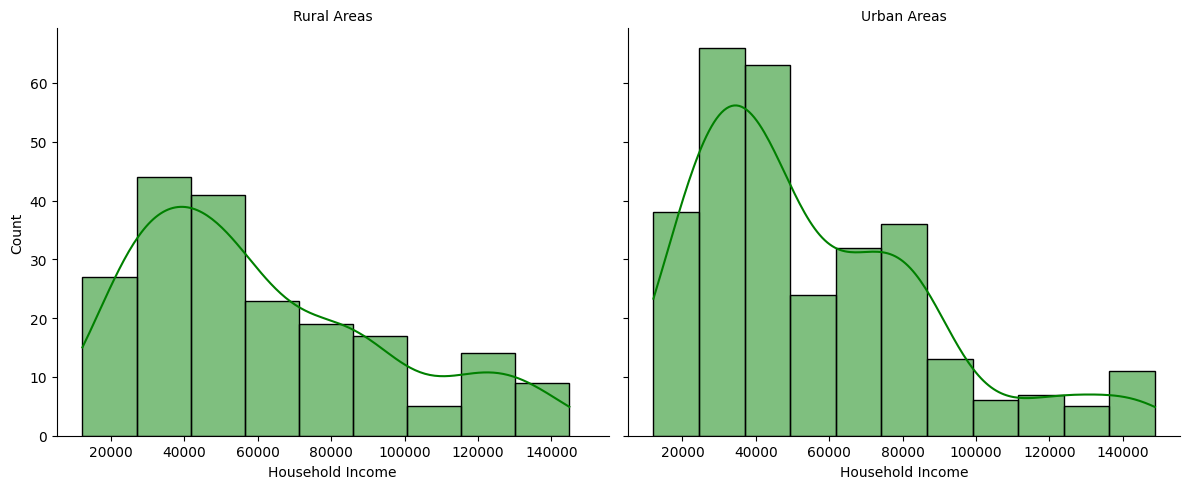

In [13]:
g = sns.FacetGrid(
    df, 
    col="Urban_Rural", 
    height=5, 
    aspect=1.2, 
    hue="Urban_Rural", 
    palette=["green", "Darkgreen"]   
)

g.map_dataframe(
    sns.histplot, 
    x="Household_Income", 
    kde=True, 
    color="green", 
    edgecolor="black"
)

g.set_axis_labels("Household Income", "Count")
g.set_titles("{col_name} Areas")

plt.show()

### Insights :- Rural vs Urban Incomes 🌾🏙️
##### - Urban areas have significantly more households overall.
##### - Both areas peak in the $30k–$50k bracket.
##### - Both show a strong right-hand skew.